# Project Title

# Loan Default Prediction Using Machine Learning

# Problem Statement

# Objective

# Dataset Description

# Importing Required Libraries

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Warnings are ignored to keep the output clean

import warnings
warnings.filterwarnings('ignore')

# Loading The Dataset

Loading the dataset using pd.read_csv() from the local system.
The dataset : synthetic_dataset (10,000,21) is stored in a DataFrame called df

In [6]:
df = pd.read_csv(r"C:\Users\Deepu\Downloads\synthetic_dataset_10000x20.csv")
df

,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,education,marital_status,region,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk
0,CUST006253,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,...,HS,Single,West,1,1,2020-07-05,6,0.404,0.141120,1
1,CUST004685,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,...,Bachelors,Married,East,0,0,2018-10-03,2,0.066,0.808496,1
2,CUST001732,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,...,Bachelors,Single,East,0,1,2018-05-30,2,0.325,0.494113,0
3,CUST004743,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,...,HS,Married,South,0,1,2018-04-22,6,0.719,-0.982453,0
4,CUST004522,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,...,Masters,Single,West,0,0,2019-12-03,1,0.324,0.898708,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CUST005735,54,44507.0,5975.0,2520.0,1,699.633352,31089.0,48,5.3,...,HS,Single,East,0,1,2020-02-27,3,0.699,-0.772764,1
9996,CUST005192,50,20651.0,10203.0,1020.0,3,680.774066,8977.0,60,9.6,...,PhD,Divorced,North,0,0,2018-08-23,3,0.435,-0.958924,0
9997,CUST005391,43,33827.0,3848.0,2562.0,1,655.562748,24319.0,60,4.3,...,HS,Married,West,0,0,2019-01-18,4,0.719,-0.916166,0
9998,CUST000861,44,38273.0,18880.0,1060.0,2,653.277645,1000.0,24,11.4,...,Other,Single,North,0,1,2019-08-04,6,0.026,-0.951602,0


# Initial EDA steps

In [7]:
# checking the dataset shape
df.shape

(10000, 21)

In [8]:
# checking the dataset information ( data_type,null or non_null columns)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          10000 non-null  object 
 1   age                  10000 non-null  int64  
 2   income               9682 non-null   float64
 3   savings              9689 non-null   float64
 4   monthly_expenses     9675 non-null   float64
 5   num_dependents       10000 non-null  int64  
 6   credit_score         9674 non-null   float64
 7   loan_amount          10000 non-null  float64
 8   loan_term_months     10000 non-null  int64  
 9   employment_years     10000 non-null  float64
 10  home_ownership       10000 non-null  object 
 11  education            10000 non-null  object 
 12  marital_status       10000 non-null  object 
 13  region               10000 non-null  object 
 14  recent_default       10000 non-null  int64  
 15  has_credit_card      10000 non-null  

In [9]:
# statistical information of numerical columns
df.describe()

,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,recent_default,has_credit_card,signup_dayofweek,debt_to_income,sin_age,target_default_risk
count,10000.000000,9682.000000,9689.000000,9675.000000,10000.000000,9674.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,45.861600,59712.871411,5039.922489,2082.209612,1.214200,650.155438,16214.796900,45.642000,5.39701,0.047000,0.694800,3.011900,0.358156,-0.100387,0.513200
std,16.457987,39865.231489,5041.793583,1385.991787,1.108982,69.918297,16081.646814,15.475134,3.41370,0.211649,0.460515,2.003986,0.302606,0.667428,0.499851
min,18.000000,20001.000000,0.000000,200.000000,0.000000,363.077116,1000.000000,12.000000,0.00000,0.000000,0.000000,0.000000,0.004000,-0.999923,0.000000
25%,32.000000,31300.500000,1476.000000,1471.000000,0.000000,602.189895,8508.500000,36.000000,2.70000,0.000000,0.000000,1.000000,0.132000,-0.756802,0.000000
50%,46.000000,47301.500000,3499.000000,2007.000000,1.000000,649.808322,15174.500000,48.000000,5.10000,0.000000,1.000000,3.000000,0.275000,-0.157746,1.000000
75%,60.000000,75164.250000,6986.000000,2557.000000,2.000000,697.537432,21843.750000,60.000000,7.70000,0.000000,1.000000,5.000000,0.508000,0.515501,1.000000
max,74.000000,402769.000000,44644.000000,28664.000000,7.000000,850.000000,441190.000000,72.000000,21.50000,1.000000,1.000000,6.000000,2.031000,0.973848,1.000000


# checking Duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

# Target Variable Analysis

In [11]:
df['target_default_risk'].value_counts()

target_default_risk
1    5132
0    4868
Name: count, dtype: int64

# Exploratory Data Analysis

# Distribution Of Numerical Analysis using Histplot

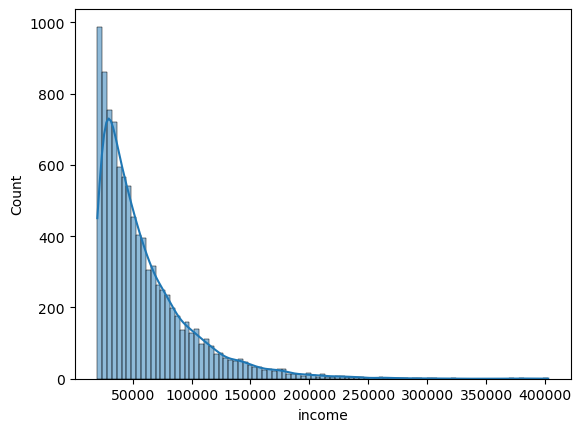

<Figure size 1500x1000 with 0 Axes>

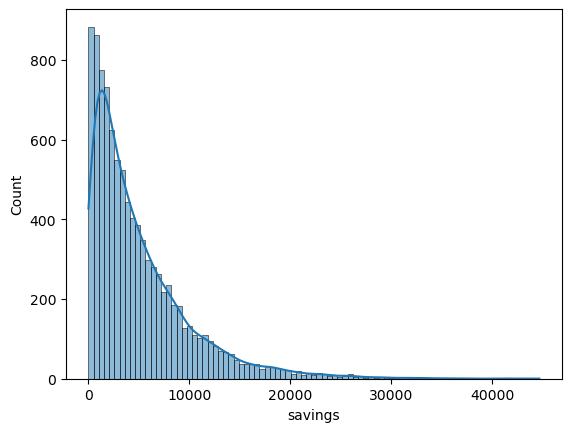

<Figure size 1500x1000 with 0 Axes>

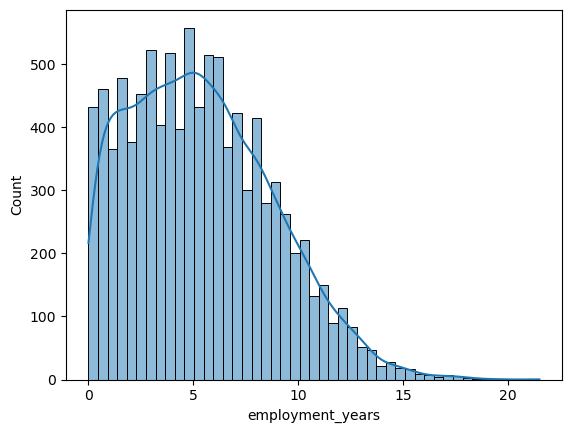

<Figure size 1500x1000 with 0 Axes>

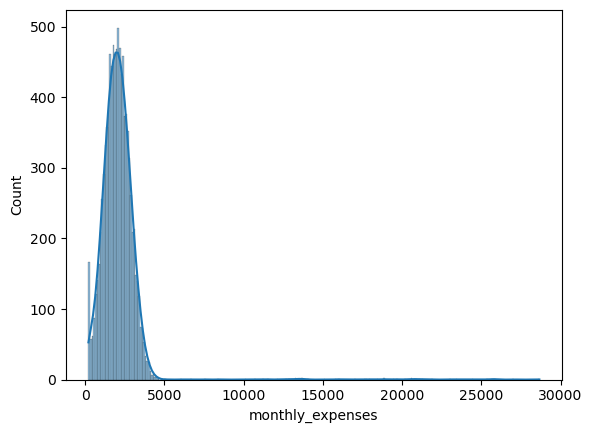

<Figure size 1500x1000 with 0 Axes>

In [12]:
cols = ['income','savings','employment_years','monthly_expenses']
for col in cols:
    sns.histplot(df[col],kde=True)
    plt.figure(figsize=(15,10))
    plt.show()


FROM THE ABOVE DISTRIBUTION:

** income
* they are very few people with income above 200,000
* from this most values are concentrated between 30,000 to 60,000
* as income increses the frequency is decreases
* This means the distribution is Right skewed(+ve skewness)

** savings
* most people have very low savings
* As savigs increase the number of people decreases
* very few people have savings above 20,000 to 40,000

** employment years
* most customers have 2 to 6 years of employment
* very few customers have 12-20 years of employment
* low employment years (0-2) higher loan risk

# Categorical Feature Distribution Analysis

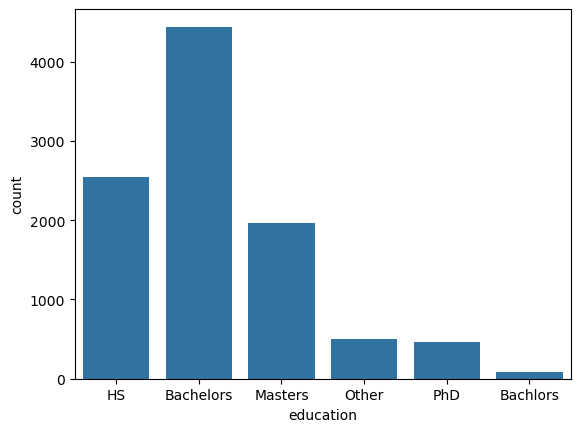

<Figure size 1500x1000 with 0 Axes>

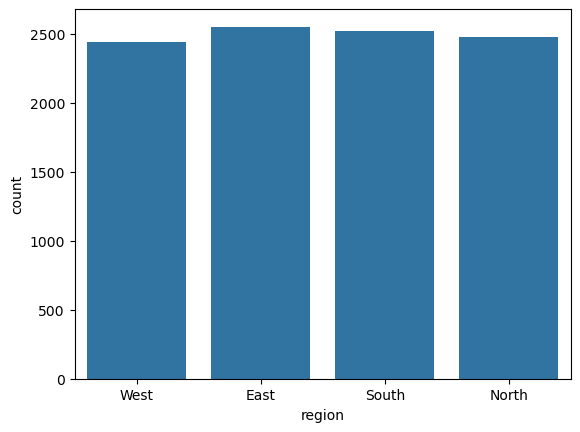

<Figure size 1500x1000 with 0 Axes>

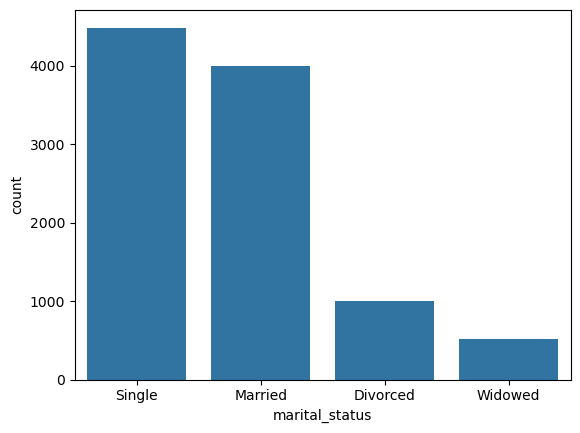

<Figure size 1500x1000 with 0 Axes>

In [13]:
columns = ['education','region','marital_status']
for col in columns:
    sns.countplot(x = df[col])
    plt.figure(figsize=(15,10))
    plt.show()

FROM THE ABOVE :
* most customers have a Bachelors Degree
* very few customers have phD
* many customers stopped education at High School

* All regions have almost same number of customers
* this means the dataset is balanced across regions

# pairwise Relationship Analysis of Numerical Features

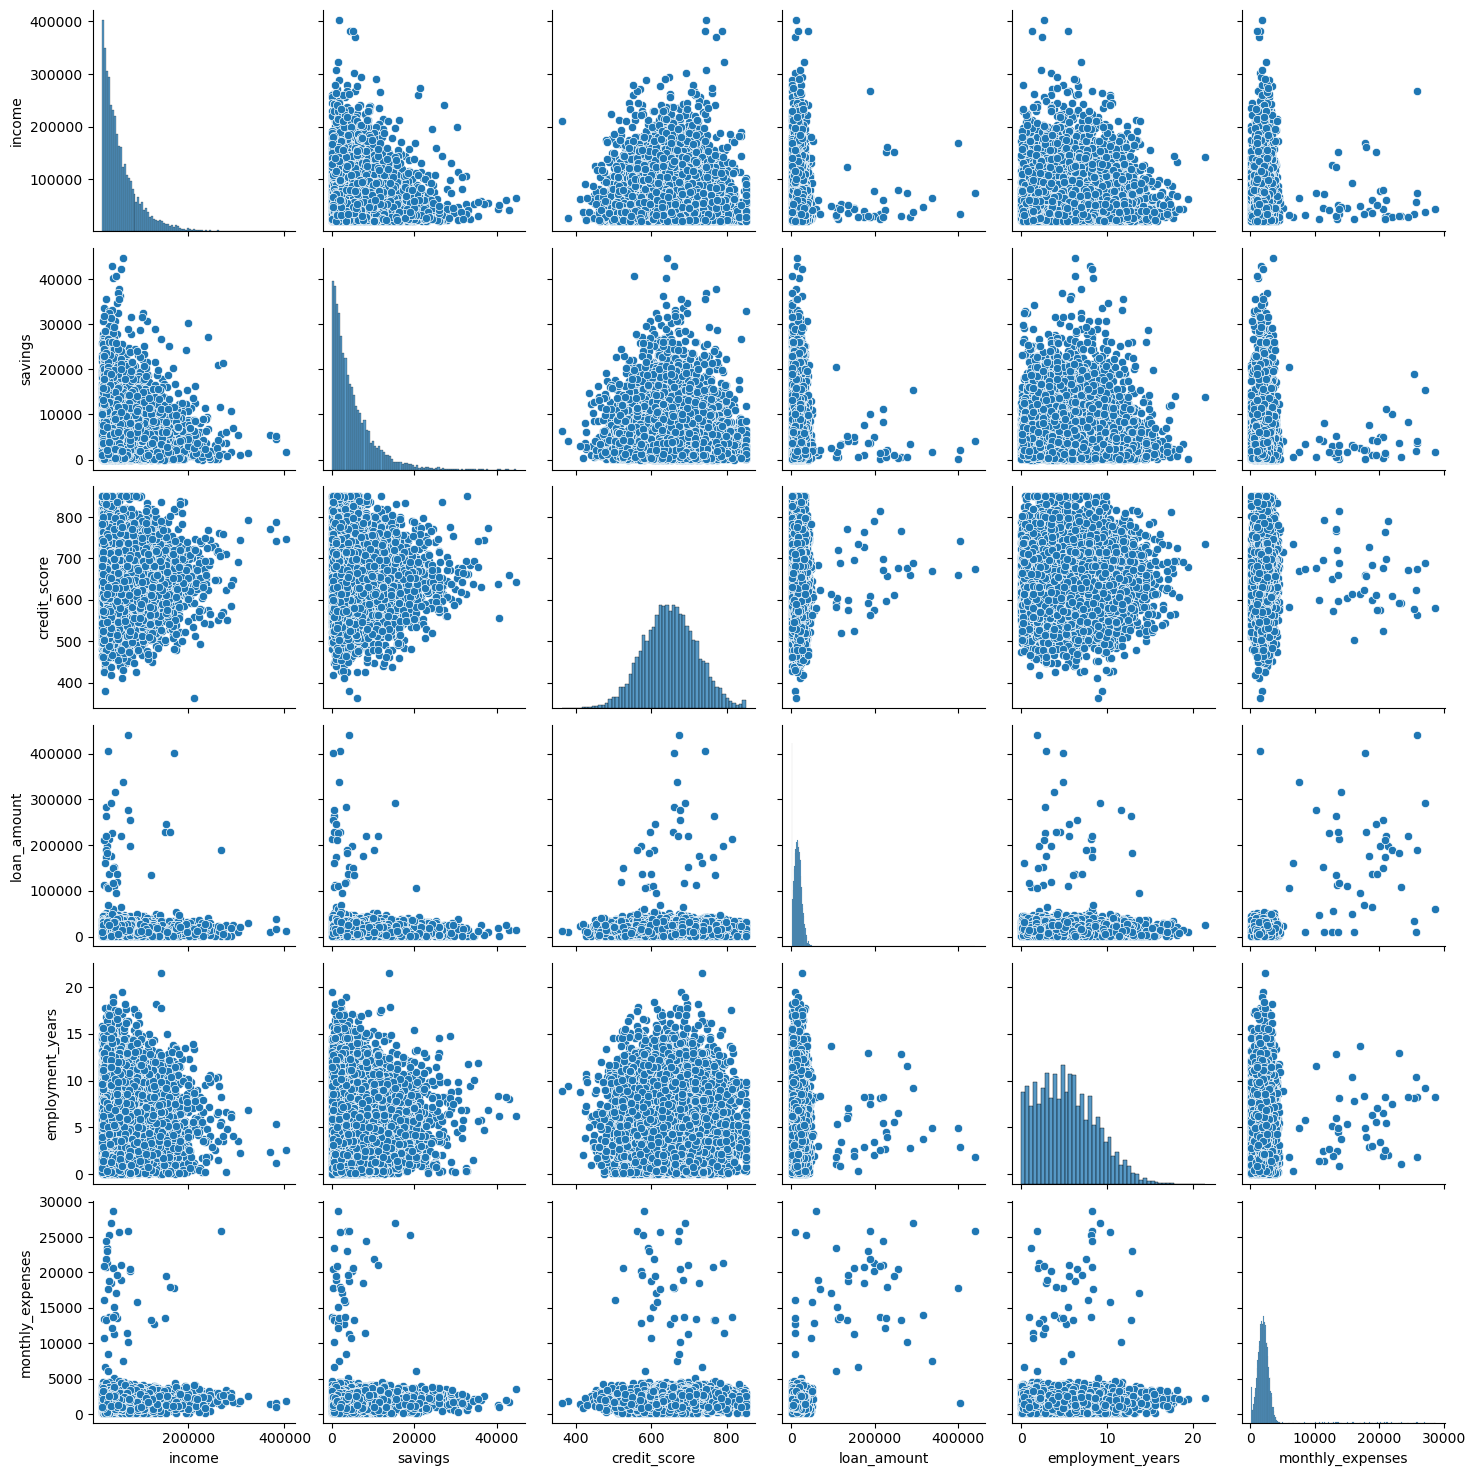

In [14]:
col = ['income','savings','credit_score','loan_amount','employment_years','monthly_expenses']
sns.pairplot(df[col])


# correlation

<Axes: >

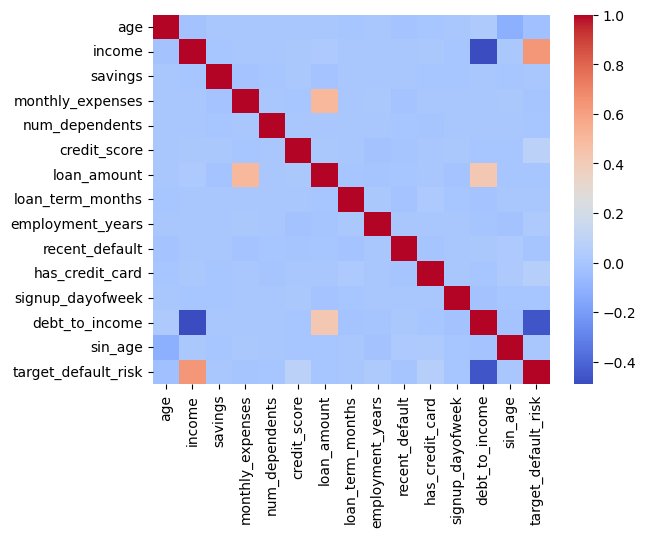

In [18]:
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), cmap='coolwarm')


# Feature Selection / Removing Irrelevant Features

In [19]:
# Removing useless columns
df = df.drop(columns=['customer_id','signup_date'])

# handling missing values using "Simple Imputer"

In [20]:
df.isnull().sum()

age                      0
income                 318
savings                311
monthly_expenses       325
num_dependents           0
credit_score           326
loan_amount              0
loan_term_months         0
employment_years         0
home_ownership           0
education                0
marital_status           0
region                   0
recent_default           0
has_credit_card          0
signup_dayofweek         0
debt_to_income           0
sin_age                  0
target_default_risk      0
dtype: int64

In [21]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='median')
num_cols = ['income','savings','monthly_expenses','credit_score']
df[num_cols] = imp.fit_transform(df[num_cols])

In [22]:
df.isnull().sum()

age                    0
income                 0
savings                0
monthly_expenses       0
num_dependents         0
credit_score           0
loan_amount            0
loan_term_months       0
employment_years       0
home_ownership         0
education              0
marital_status         0
region                 0
recent_default         0
has_credit_card        0
signup_dayofweek       0
debt_to_income         0
sin_age                0
target_default_risk    0
dtype: int64

# Handling Incosistent or missspelled values

In [23]:
df['education'] = df['education'].replace('Bachlors','Bachelors')

# Handling Outliers Using IQR method [Using Box Plot ]

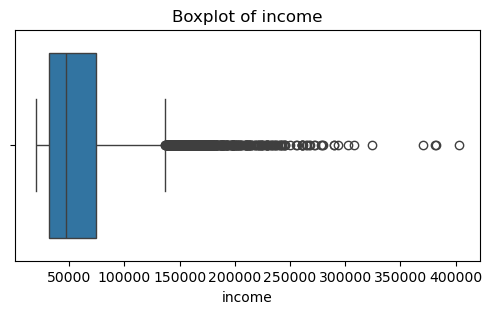

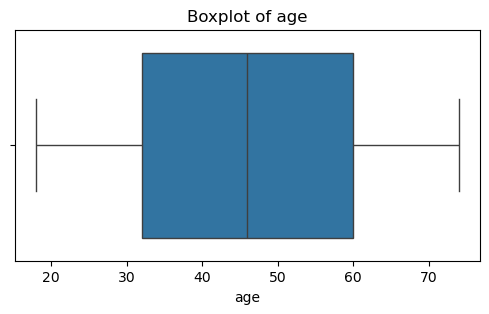

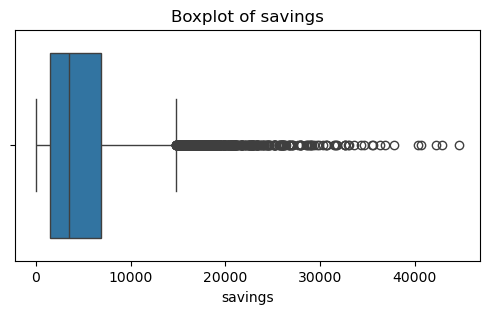

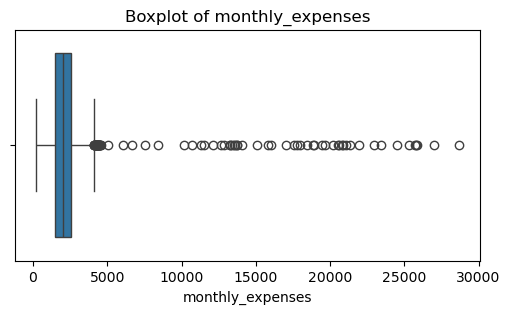

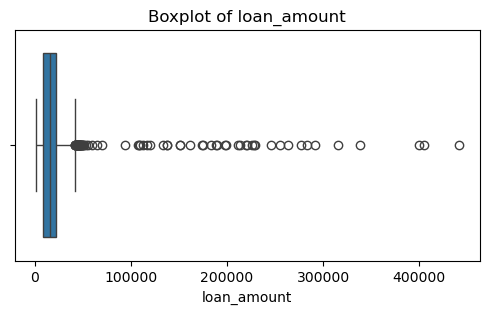

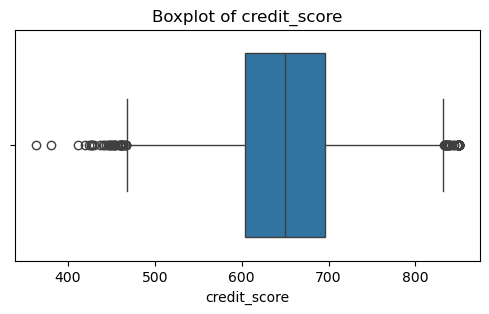

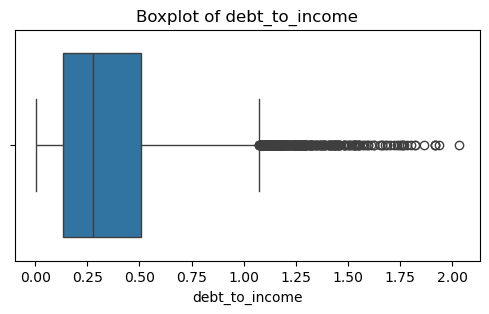

In [24]:
num_cols = ['income','age','savings','monthly_expenses','loan_amount','credit_score','debt_to_income']

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=col,data=df)
    plt.title(f'Boxplot of {col}')
    plt.show()

In [25]:
cols=['income','savings','monthly_expenses','num_dependents','credit_score','loan_amount','debt_to_income','employment_years']

for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3-q1

    lower = q1-1.5*iqr
    upper = q3+1.5*iqr

    df[col] = df[col].clip(lower,upper)

In [26]:
df

,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,home_ownership,education,marital_status,region,recent_default,has_credit_card,signup_dayofweek,debt_to_income,sin_age,target_default_risk
0,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,RENT,HS,Single,West,1,1,6,0.404,0.141120,1
1,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,RENT,Bachelors,Married,East,0,0,2,0.066,0.808496,1
2,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,OWN,Bachelors,Single,East,0,1,2,0.325,0.494113,0
3,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,OWN,HS,Married,South,0,1,6,0.719,-0.982453,0
4,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,MORTGAGE,Masters,Single,West,0,0,1,0.324,0.898708,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,54,44507.0,5975.0,2520.0,1,699.633352,31089.0,48,5.3,RENT,HS,Single,East,0,1,3,0.699,-0.772764,1
9996,50,20651.0,10203.0,1020.0,3,680.774066,8977.0,60,9.6,RENT,PhD,Divorced,North,0,0,3,0.435,-0.958924,0
9997,43,33827.0,3848.0,2562.0,1,655.562748,24319.0,60,4.3,OTHER,HS,Married,West,0,0,4,0.719,-0.916166,0
9998,44,38273.0,14770.0,1060.0,2,653.277645,1000.0,24,11.4,MORTGAGE,Other,Single,North,0,1,6,0.026,-0.951602,0


In [27]:
df.shape

(10000, 19)

# Splitting Features and Target Variable

In [31]:
x = df.drop('target_default_risk',axis=1)
y = df['target_default_risk']

# Splitting Data into train & test

In [32]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test =  train_test_split(x,y,test_size=0.2,random_state=42)

# Encoding categorical variables

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

In [34]:
trans = ColumnTransformer(transformers = [
    ('tnf1',OrdinalEncoder(),['education']),
    ('tnf2',OneHotEncoder(sparse_output=False,drop='first'),['home_ownership','marital_status','region']),
],remainder = 'passthrough')


In [35]:
x_train = trans.fit_transform(x_train)
x_test = trans.transform(x_test)

# feature Scaling

In [36]:
from sklearn.preprocessing import StandardScaler
sc =  StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

# Model Training and Evaluation(Logistic Regression)

In [37]:
from sklearn.linear_model import LogisticRegression
mod1 = LogisticRegression()
mod1.fit(x_train,y_train)

LogisticRegression()

In [38]:
y_pred = mod1.predict(x_test)

In [43]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [40]:
print("accuracy:",accuracy_score(y_test,y_pred))

accuracy: 0.9425


In [41]:
print(confusion_matrix(y_test,y_pred))

[[942  27]
 [ 88 943]]


In [44]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       969
           1       0.97      0.91      0.94      1031

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



In [42]:
pd.Series(y_pred).value_counts()

0    1030
1     970
Name: count, dtype: int64

# Model Training and Evaluation (Decision Tree)

In [54]:
from sklearn.tree import DecisionTreeClassifier
mod2 = DecisionTreeClassifier()
mod2.fit(x_train,y_train)


DecisionTreeClassifier()

In [55]:
y_pred1 = mod2.predict(x_test)
y_pred1


array([0, 0, 1, ..., 0, 1, 0])

In [56]:
pd.Series(y_pred1).value_counts()

1    1015
0     985
Name: count, dtype: int64

In [57]:
print(accuracy_score(y_test,y_pred1))

0.926


In [58]:
pd.Series(y_test).value_counts()

target_default_risk
1    1031
0     969
Name: count, dtype: int64

# Model Training and Evaluation(SVM)

In [59]:
from sklearn.svm import SVC
mod3 = SVC()

# Hyperparameter Tuning for svm

In [60]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':[0.1,1,10],
    'kernel':['linear','rbf'],
    'gamma':['scale','auto']
}
grid = GridSearchCV(mod3,param_grid,cv=5)
grid.fit(x_train,y_train)
print("best parameters:",grid.best_params_)

best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [61]:
y_pred2 = grid.predict(x_test)
y_pred2

array([0, 0, 1, ..., 0, 1, 0])

In [62]:
print(accuracy_score(y_test,y_pred2))

0.952


In [63]:
print(confusion_matrix(y_test,y_pred2))

[[946  23]
 [ 73 958]]


# Model Training and Evaluation(Random Forest)

In [64]:
from sklearn.ensemble import RandomForestClassifier
mod4 = RandomForestClassifier()

# hyperparameter tuning for Random Forest

In [65]:
from sklearn.model_selection import GridSearchCV

param_grid1 = {
    'n_estimators':[100,200,300],
    'max_depth':[None,5,10],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2],
    'max_features':['sqrt','log2']
}
grid1 = GridSearchCV(mod4,param_grid1,cv=5,n_jobs=-1)
grid1.fit(x_train,y_train)
print("best parameter:",grid1.best_params_)


best parameter: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [66]:
y_pred3 = grid1.predict(x_test)
y_pred3

array([0, 0, 1, ..., 0, 1, 0])

In [67]:
print(accuracy_score(y_test,y_pred3))

0.9425


# Model Training and Evaluation(XGBOOST)

In [68]:
!pip install xgboost

In [69]:
from xgboost import XGBClassifier
mod5 = XGBClassifier()

In [79]:
from sklearn.model_selection import GridSearchCV

param_grid2 = {
    'n_estimators':[200,300],
    'max_depth':[6],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.7,0.8,1],
    'colsample_bytree':[0.7,0.8,1],
    'gamma':[0,0.01,0.2]
}
grid2 = GridSearchCV(mod5,param_grid2,cv=10,n_jobs=-1)
grid2.fit(x_train,y_train)
print("best parameter:",grid2.best_params_)

best parameter: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}


In [80]:
y_pred4 = grid2.predict(x_test)
y_pred4

array([0, 0, 1, ..., 0, 1, 0])

In [81]:
print(accuracy_score(y_test,y_pred4))

0.959


# Conclusion